# Разведочный анализ

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv
import clickhouse_connect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [2]:
# Определяем путь к .env файлу относительно текущего ноутбука
env_path = Path.cwd().parent / 'infrastructure' / '.env'
# Загружаем переменные из указанного пути
if env_path.exists():
    load_dotenv(dotenv_path=env_path)
    print(f"Конфигурация загружена из: {env_path}")
else:
    print(f"Файл .env не найден по пути: {env_path}")

Конфигурация загружена из: /home/andrew/oncology_fhir_analytics/infrastructure/.env


In [5]:
# Подключаемся к ClickHouse
client = clickhouse_connect.get_client(
    host='localhost',
    port=8123,
    username=os.getenv('CLICKHOUSE_USER', 'default'),
    password=os.getenv('CLICKHOUSE_PASSWORD', ''),
    database=os.getenv('CLICKHOUSE_DB', 'default')
)

def query_df(sql):
    return client.query_df(sql)

print("Подключение установлено.")

Подключение установлено.


## Анализ пациентов

In [14]:
df_patients = query_df("""
SELECT 
    gender, 
    race, 
    ethnicity,
    dateDiff('year', birth_date, today()) as age,
    is_deceased
FROM oncology.patients
""")

In [15]:
df_patients.head()

,gender,race,ethnicity,age,is_deceased
0,male,White,Not Hispanic or Latino,90,0
1,female,White,Not Hispanic or Latino,89,1
2,female,White,Not Hispanic or Latino,56,0
3,female,White,Not Hispanic or Latino,84,1
4,female,White,Not Hispanic or Latino,88,1


In [16]:
print("Статистика по возрасту:")
print(df_patients['age'].describe())

Статистика по возрасту:
count      10673.0
mean     76.106343
std      12.040693
min           45.0
25%           68.0
50%           80.0
75%           86.0
max           90.0
Name: age, dtype: Float64


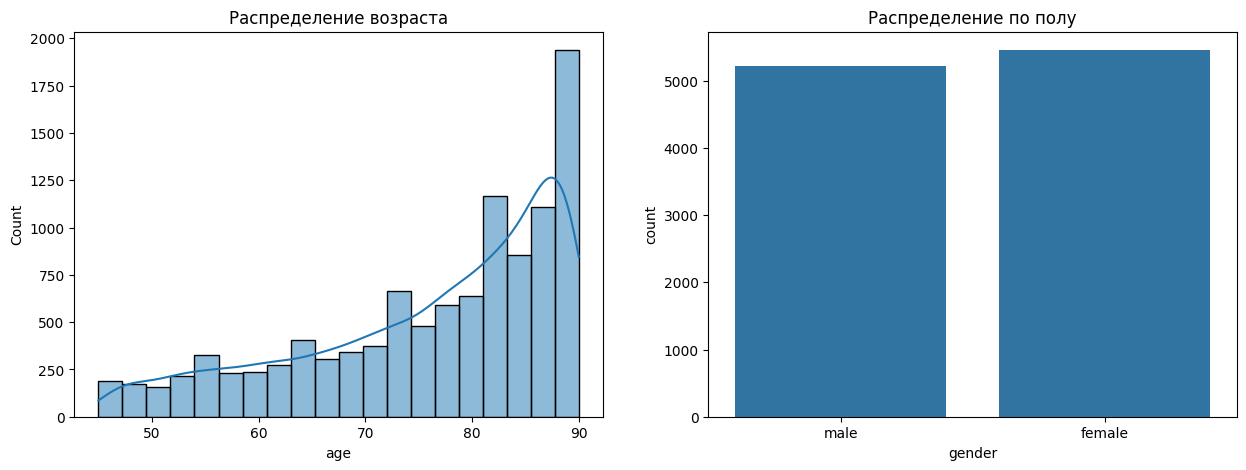

In [17]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df_patients['age'], bins=20, kde=True, ax=axes[0]).set_title('Распределение возраста')
sns.countplot(data=df_patients, x='gender', ax=axes[1]).set_title('Распределение по полу')
plt.show()

## Анализ диагнозов

In [ ]:
# Проверим наличие указанных вами кодов в базе
target_codes = ['68496003', '713197008', '93761005', '109838007', '363406005', '94260004']

df_cond_stats = query_df(f"""
SELECT 
    code, 
    display, 
    count() as cnt,
    count(DISTINCT patient_id) as unique_patients
FROM oncology.conditions
WHERE code IN {tuple(target_codes)}
GROUP BY code, display
ORDER BY cnt DESC
""")
print("Статистика по целевым кодам SNOMED:")
df_cond_stats

Статистика по целевым кодам SNOMED:


,code,display,cnt,unique_patients
0,68496003,Polyp of colon (disorder),8024,6452
1,713197008,Recurrent rectal polyp (disorder),3927,3842
2,109838007,Overlapping malignant neoplasm of colon (disor...,2404,2404
3,363406005,Malignant neoplasm of colon (disorder),2136,2136
4,93761005,Primary malignant neoplasm of colon (disorder),1133,1133
5,94260004,Metastatic malignant neoplasm to colon (disorder),30,30


## Анализ витрины объединенных данных patients и conditions

### Создание витрины

In [ ]:
sql_mart = """
WITH patient_groups AS (
    SELECT 
        patient_id,
        -- Определяем категорию ТОЛЬКО для тех, кто есть в таблице conditions
        multiIf(
            hasAny(groupArray(code), ['93761005', '109838007', '363406005', '94260004']), 'CRC',
            hasAny(groupArray(code), ['68496003', '713197008']), 'Polyp',
            'Control'
        ) as category
    FROM oncology.conditions
    GROUP BY patient_id
)
SELECT 
    p.patient_id,
    p.gender,
    p.race,
    dateDiff('year', p.birth_date, today()) as age,
    p.is_deceased,
    -- Если в g.category пусто или NULL, пишем 'Control'
    if(g.category = '' OR isNull(g.category), 'Control', g.category) as patient_group,
    -- Превращаем NULL в 0
    COALESCE((SELECT count() FROM oncology.observations o WHERE o.patient_id = p.patient_id), 0) as obs_count,
    COALESCE((SELECT count() FROM oncology.procedures pr WHERE pr.patient_id = p.patient_id), 0) as proc_count
FROM oncology.patients p
LEFT JOIN patient_groups g ON p.patient_id = g.patient_id
"""

df_mart = query_df(sql_mart)
print(f"Витрина загружена: {df_mart.shape[0]} пациентов")

Витрина загружена: 10673 пациентов


In [56]:
df_mart.head()

,patient_id,gender,race,age,is_deceased,patient_group,obs_count,proc_count
0,81c3347d-4bf5-82bd-7804-dfd8c3644328,male,White,74,0,Control,0,5
1,766c3960-68c7-6da4-0267-96fca4e155c3,male,Black or African American,90,1,CRC,173,18
2,79155e97-0493-cd03-91d1-f5d212cc3f93,female,White,53,0,CRC,183,17
3,10027f14-b0d7-c853-9888-22eb9b8d6659,male,White,85,1,CRC,16,15
4,bcc59537-9e5b-3f9d-e97b-790cd6277aa6,male,White,72,1,CRC,186,19


Распределение диагнозов по группам

In [70]:
group_counts = df_mart['patient_group'].value_counts(dropna=False).reset_index()
total = group_counts['count'].sum()
group_counts['percentage'] = (group_counts['count'] / total * 100).round(2)
group_counts

,patient_group,count,percentage
0,CRC,5703,53.43
1,Control,3877,36.33
2,Polyp,1093,10.24
